In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


In [2]:
ROOT = Path.cwd().parent
DATA_DIR = ROOT / 'data'


In [3]:
accounts_df = pd.read_csv(DATA_DIR / 'accounts.csv')
sar_accounts_df = pd.read_csv(DATA_DIR / 'sar_accounts.csv')
tx_count_df = pd.read_csv(DATA_DIR / 'tx_count.csv')
tx_log_df = pd.read_csv(DATA_DIR / 'tx_log.csv')


In [4]:
merged_df = tx_log_df.merge(
    accounts_df.add_prefix('orig_'),
    left_on='nameOrig',
    right_on='orig_acct_id',
    how='left'
)

merged_df = merged_df.merge(
    accounts_df.add_prefix('dest_'),
    left_on='nameDest',
    right_on='dest_acct_id',
    how='left'
)


In [5]:
alert_meta = sar_accounts_df[['ALERT_ID', 'ALERT_TYPE']].drop_duplicates('ALERT_ID')

merged_df = merged_df.merge(
    alert_meta,
    left_on='alertID',
    right_on='ALERT_ID',
    how='left'
)

merged_df['ALERT_TYPE'] = merged_df['ALERT_TYPE'].fillna('none')


In [6]:
merged_df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrig',
       'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest',
       'isSAR', 'alertID', 'orig_acct_id', 'orig_dsply_nm', 'orig_type',
       'orig_acct_stat', 'orig_acct_rptng_crncy', 'orig_prior_sar_count',
       'orig_branch_id', 'orig_open_dt', 'orig_close_dt',
       'orig_initial_deposit', 'orig_tx_behavior_id', 'orig_bank_id',
       'orig_first_name', 'orig_last_name', 'orig_street_addr', 'orig_city',
       'orig_state', 'orig_country', 'orig_zip', 'orig_gender',
       'orig_birth_date', 'orig_ssn', 'orig_lon', 'orig_lat', 'dest_acct_id',
       'dest_dsply_nm', 'dest_type', 'dest_acct_stat', 'dest_acct_rptng_crncy',
       'dest_prior_sar_count', 'dest_branch_id', 'dest_open_dt',
       'dest_close_dt', 'dest_initial_deposit', 'dest_tx_behavior_id',
       'dest_bank_id', 'dest_first_name', 'dest_last_name', 'dest_street_addr',
       'dest_city', 'dest_state', 'dest_country', 'dest_zip', 'dest_gender

In [7]:
drop_list = [
    'type',
    'orig_type',
    'dest_type',
    'orig_acct_stat',
    'dest_acct_stat',
    'orig_acct_rptng_crncy',
    'dest_acct_rptng_crncy',
    'orig_bank_id',
    'dest_bank_id',
    'orig_country',
    'dest_country',
    'orig_tx_behavior_id',
    'dest_tx_behavior_id',
    'orig_close_dt',
    'dest_close_dt',
    'alertID',
    'ALERT_ID',
    'orig_dsply_nm',
    'dest_dsply_nm',
    'orig_ssn',
    'dest_ssn',
    'orig_first_name',
    'orig_last_name',
    'dest_first_name',
    'dest_last_name',
    'orig_street_addr',
    'dest_street_addr',
    'orig_zip',
    'dest_zip',
    'orig_lat',
    'dest_lat',
    'orig_lon',
    'dest_lon',
    'orig_gender',
    'dest_gender',
    'ALERT_TYPE',
    'orig_branch_id',
    'dest_branch_id',
    'orig_open_dt',
    'dest_open_dt',
    'orig_city',
    'dest_city',
    'orig_state',
    'dest_state',
    'orig_birth_date',
    'dest_birth_date',
    'orig_acct_id',
    'dest_acct_id',
]

merged_df = merged_df.drop(columns=drop_list)


In [8]:
merged_df.columns

Index(['step', 'amount', 'nameOrig', 'oldbalanceOrig', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isSAR',
       'orig_prior_sar_count', 'orig_initial_deposit', 'dest_prior_sar_count',
       'dest_initial_deposit'],
      dtype='object')

In [9]:
merged_df['log_amount'] = np.log1p(merged_df['amount'])
merged_df['hour_of_day'] = merged_df['step'] % 24
merged_df['day'] = merged_df['step'] // 24
merged_df['log_orig_balance_error'] = np.log1p((merged_df['oldbalanceOrig'] - merged_df['newbalanceOrig'] - merged_df['amount']).abs())
merged_df['log_dest_balance_error'] = np.log1p((merged_df['newbalanceDest'] - merged_df['oldbalanceDest'] - merged_df['amount']).abs())
merged_df['orig_sent_fraction'] = merged_df['amount'] / (merged_df['oldbalanceOrig'] + 1)
merged_df['log_dest_recv_fraction'] = np.log1p(merged_df['amount'] / (merged_df['oldbalanceDest'] + 1))
merged_df['near_10k'] = ((merged_df['amount'] >= 9_000) & (merged_df['amount'] < 10_000)).astype(int)
merged_df['amount_vs_orig_deposit'] = merged_df['amount'] / (merged_df['orig_initial_deposit'] + 1)
merged_df['amount_vs_dest_deposit'] = merged_df['amount'] / (merged_df['dest_initial_deposit'] + 1)


In [10]:
merged_df = merged_df.drop(columns=['oldbalanceOrig', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest'])


In [11]:
merged_df.columns

Index(['step', 'amount', 'nameOrig', 'nameDest', 'isSAR',
       'orig_prior_sar_count', 'orig_initial_deposit', 'dest_prior_sar_count',
       'dest_initial_deposit', 'log_amount', 'hour_of_day', 'day',
       'log_orig_balance_error', 'log_dest_balance_error',
       'orig_sent_fraction', 'log_dest_recv_fraction', 'near_10k',
       'amount_vs_orig_deposit', 'amount_vs_dest_deposit'],
      dtype='object')

In [12]:
merged_df = merged_df.sort_values('step').reset_index(drop=True)
merged_df['log_orig_tx_count'] = np.log1p(merged_df.groupby('nameOrig').cumcount())
merged_df['log_orig_total_sent'] = np.log1p(merged_df.groupby('nameOrig')['amount'].cumsum() - merged_df['amount'])
merged_df['orig_avg_sent'] = merged_df['log_orig_total_sent'] / (merged_df['log_orig_tx_count'] + 1)
merged_df['log_dest_tx_count'] = np.log1p(merged_df.groupby('nameDest').cumcount())
merged_df['log_dest_total_recv'] = np.log1p(merged_df.groupby('nameDest')['amount'].cumsum() - merged_df['amount'])
merged_df['dest_avg_recv'] = merged_df['log_dest_total_recv'] / (merged_df['log_dest_tx_count'] + 1)
merged_df['_is_new_pair'] = (~merged_df.duplicated(subset=['nameOrig', 'nameDest'], keep='first')).astype(int)
merged_df['log_dest_unique_senders'] = np.log1p(merged_df.groupby('nameDest')['_is_new_pair'].cumsum() - merged_df['_is_new_pair'])
merged_df['log_orig_unique_recipients'] = np.log1p(merged_df.groupby('nameOrig')['_is_new_pair'].cumsum() - merged_df['_is_new_pair'])
merged_df['orig_prior_sar_count'] = merged_df['orig_prior_sar_count'].astype(int)
merged_df['dest_prior_sar_count'] = merged_df['dest_prior_sar_count'].astype(int)
merged_df = merged_df.drop(columns=['_is_new_pair', 'nameOrig', 'nameDest', 'amount', 'step'])


In [13]:
merged_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 896914 entries, 0 to 896913
Data columns (total 23 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   isSAR                       896914 non-null  int64  
 1   orig_prior_sar_count        896914 non-null  int64  
 2   orig_initial_deposit        896914 non-null  float64
 3   dest_prior_sar_count        896914 non-null  int64  
 4   dest_initial_deposit        896914 non-null  float64
 5   log_amount                  896914 non-null  float64
 6   hour_of_day                 896914 non-null  int64  
 7   day                         896914 non-null  int64  
 8   log_orig_balance_error      896914 non-null  float64
 9   log_dest_balance_error      896914 non-null  float64
 10  orig_sent_fraction          896914 non-null  float64
 11  log_dest_recv_fraction      896914 non-null  float64
 12  near_10k                    896914 non-null  int64  
 13  amount_vs_orig

In [14]:
merged_df.describe()


,isSAR,orig_prior_sar_count,orig_initial_deposit,dest_prior_sar_count,dest_initial_deposit,log_amount,hour_of_day,day,log_orig_balance_error,log_dest_balance_error,...,amount_vs_orig_deposit,amount_vs_dest_deposit,log_orig_tx_count,log_orig_total_sent,orig_avg_sent,log_dest_tx_count,log_dest_total_recv,dest_avg_recv,log_dest_unique_senders,log_orig_unique_recipients
count,896914.000000,896914.000000,896914.000000,896914.000000,896914.000000,896914.000000,896914.000000,896914.000000,8.969140e+05,896914.000000,...,8.969140e+05,8.969140e+05,896914.000000,896914.000000,896914.000000,896914.000000,896914.000000,896914.000000,896914.000000,896914.000000
mean,0.008067,0.718592,760493.722997,0.814773,771602.105951,8.109686,11.450756,12.103374,4.300663e-02,2.122698,...,6.528772e-03,6.469075e-03,4.057176,12.438382,2.510832,6.586680,15.004262,2.072948,4.197808,1.450507
std,0.089451,0.449686,144558.806317,0.388482,146596.025704,1.097052,6.923084,8.253431,4.673231e-01,3.476279,...,4.307379e-03,4.297420e-03,1.043652,1.659696,0.491159,2.134166,2.520033,0.498280,1.795196,0.760635
min,0.000000,0.000000,500066.320000,0.000000,500066.320000,0.039221,0.000000,0.000000,0.000000e+00,0.000000,...,4.692556e-08,7.851677e-08,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,636748.320000,1.000000,646136.620000,7.688396,5.000000,5.000000,5.593392e-11,0.029559,...,2.871412e-03,2.829163e-03,3.610918,12.095354,2.297114,5.099866,13.606837,1.799772,2.833213,1.098612
50%,0.000000,1.000000,767714.700000,1.000000,774120.240000,8.464234,11.000000,11.000000,9.950331e-03,0.122218,...,6.220886e-03,6.151054e-03,4.304065,12.807699,2.410472,7.101676,15.617552,1.921503,4.859812,1.098612
75%,0.000000,1.000000,886161.100000,1.000000,912586.070000,8.903586,17.000000,18.000000,1.980263e-02,4.109890,...,9.645584e-03,9.544988e-03,4.762174,13.271808,2.612425,8.354910,16.866017,2.213681,5.723585,1.791759
max,1.000000,1.000000,999973.910000,1.000000,999973.910000,9.210439,23.000000,29.000000,9.209159e+00,9.210422,...,1.998767e-02,1.995589e-02,6.025866,14.540390,5.439753,9.532714,18.011364,5.439829,6.267201,4.709530


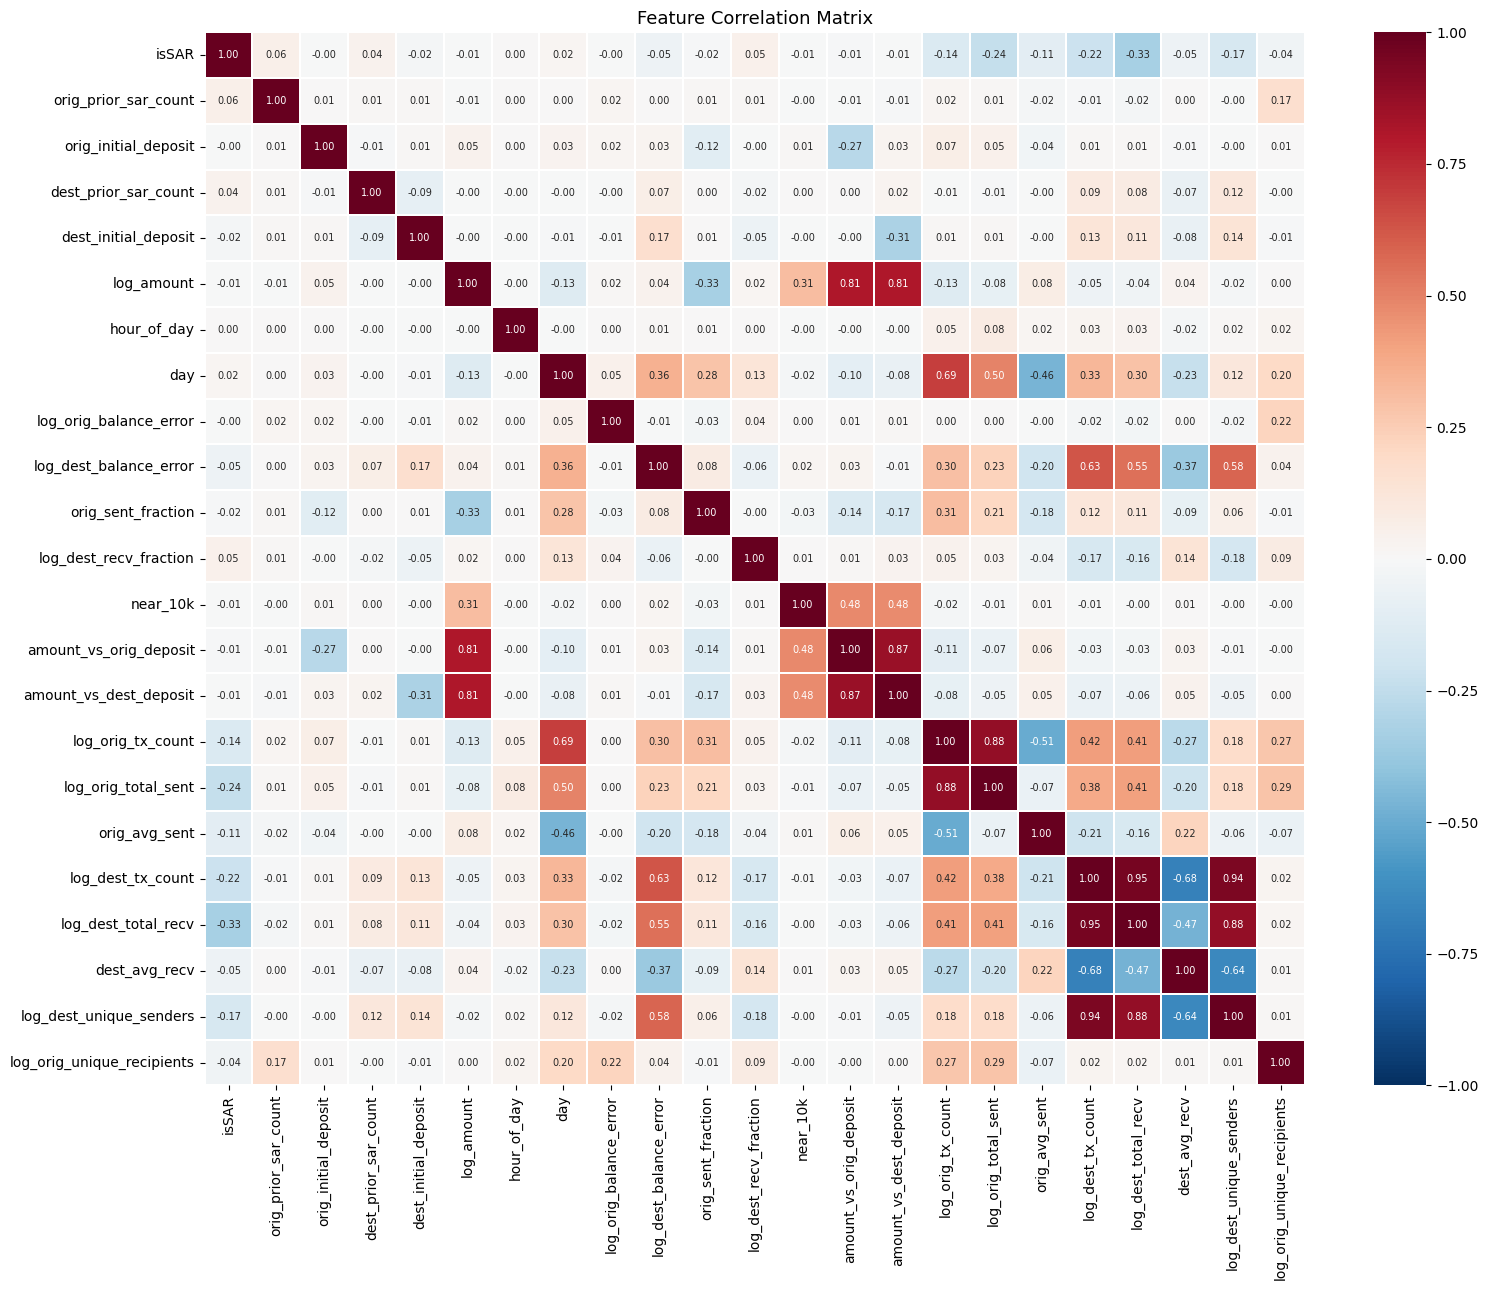

orig_prior_sar_count          0.056433
log_dest_recv_fraction        0.051433
dest_prior_sar_count          0.042997
day                           0.020288
hour_of_day                   0.002459
log_orig_balance_error       -0.001001
orig_initial_deposit         -0.004197
amount_vs_dest_deposit       -0.005608
log_amount                   -0.006532
near_10k                     -0.006988
amount_vs_orig_deposit       -0.009105
orig_sent_fraction           -0.015142
dest_initial_deposit         -0.016409
log_orig_unique_recipients   -0.041981
log_dest_balance_error       -0.053388
dest_avg_recv                -0.053541
orig_avg_sent                -0.105177
log_orig_tx_count            -0.140850
log_dest_unique_senders      -0.169786
log_dest_tx_count            -0.217504
log_orig_total_sent          -0.236461
log_dest_total_recv          -0.330007


In [15]:
plot_df = merged_df.copy()
corr = plot_df.corr()

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    annot_kws={'size': 7},
    ax=ax
)
ax.set_title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

# isSAR column sorted separately for easy reading
print(corr['isSAR'].drop('isSAR').sort_values(ascending=False).to_string())
